Fisher's exact test is a statistical method used to determine if there are nonrandom associations between two categorical variables

In [2]:

import os
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

complex_labels = {
    "complex_i": "Complex I",
    "complex_ii": "Complex II",
    "complex_iii": "Complex III",
    "complex_iv": "Complex IV",
    "complex_v": "Complex V"
}


STRING_DIR = "../data/interim/STRING_output"

subtypes = [
    "classical",
    "mesenchymal",
    "proneural"
]

PATHWAY_DIR = "../data/processed/pathway_diff"
OXPHOS_DIR = "../data/processed/oxphos"

pathways = [
    "Apoptosis",
    "Autophagy",
    "Ferroptosis",
    "Necroptosis",
    "Pyroptosis"
]

complexes = [
    "complex_i",
    "complex_ii",
    "complex_iii",
    "complex_iv",
    "complex_v"
]

graphs = {}



for subtype in subtypes:

    from collections import defaultdict

    gene_annotation = defaultdict(lambda: {
        "pathways": set(),
        "complexes": set()
    })

    ####################################################
    # Load pathway annotations
    ####################################################
    
    for pathway in pathways:

        file = os.path.join(
            PATHWAY_DIR,
            subtype,
            f"{subtype}_{pathway}_diff.csv"
        )

        df = pd.read_csv(file, index_col=0)

        df.index = df.index.astype(str).str.upper()

        for gene in df.index:
            gene_annotation[gene]["pathways"].add(pathway)

    
    ####################################################
    # Load complex annotations
    ####################################################

    for complex_name in complexes:

        file = os.path.join(
            OXPHOS_DIR,
            subtype,
            f"{subtype}_{complex_name}.csv"
        )

        df = pd.read_csv(file, index_col=0)

        df.index = df.index.astype(str).str.upper()

        for gene in df.index:
            gene_annotation[gene]["complexes"].add(
                complex_labels[complex_name]
            )

    ####################################################
    # Load STRING network
    ####################################################

    file = os.path.join(
        STRING_DIR,
        f"{subtype}_string_interactions.tsv"
    )

    interactions = pd.read_csv(
        file,
        sep="\t"
    )

    G = nx.from_pandas_edgelist(
        interactions,
        source="#node1",
        target="node2",
        edge_attr=True,
        create_using=nx.Graph()
    )

    graphs[subtype] = G

    for gene in G.nodes():
        G.nodes[gene]["Pathways"] = list(
            gene_annotation[gene]["pathways"]
        )

        G.nodes[gene]["Complexes"] = list(
            gene_annotation[gene]["complexes"]
        )

    annotation = []

    for gene in G.nodes():

        annotation.append({

            "Gene": gene,

            "Pathways": ";".join(G.nodes[gene]["Pathways"]),

            "Complexes": ";".join(G.nodes[gene]["Complexes"])

        })

    annotation = pd.DataFrame(annotation)

    annotation.to_csv(
        f"../data/interim/network_stat/{subtype}_annotations.csv",
        index=False
    )
    

    
    degree = dict(G.degree())
    betweenness = nx.betweenness_centrality(G)
    closeness = nx.closeness_centrality(G)
    pagerank = nx.pagerank(G)

    stats = pd.DataFrame({
        "Gene": list(G.nodes()),
        "Degree": [degree[g] for g in G.nodes()],
        "Betweenness": [betweenness[g] for g in G.nodes()],
        "Closeness": [closeness[g] for g in G.nodes()],
        "PageRank": [pagerank[g] for g in G.nodes()]
    })

    stats.sort_values(
        "Degree",
        ascending=False
    ).to_csv(
        os.path.join(

            f"../data/interim/network_stat/{subtype}_network_statistics.csv"
        ),
        index=False
    )
    print(f"{subtype.capitalize()}")
    print(f"Nodes : {G.number_of_nodes()}")
    print(f"Edges : {G.number_of_edges()}")
    print("-" * 30)


Classical
Nodes : 218
Edges : 5288
------------------------------
Mesenchymal
Nodes : 240
Edges : 5544
------------------------------
Proneural
Nodes : 203
Edges : 4989
------------------------------


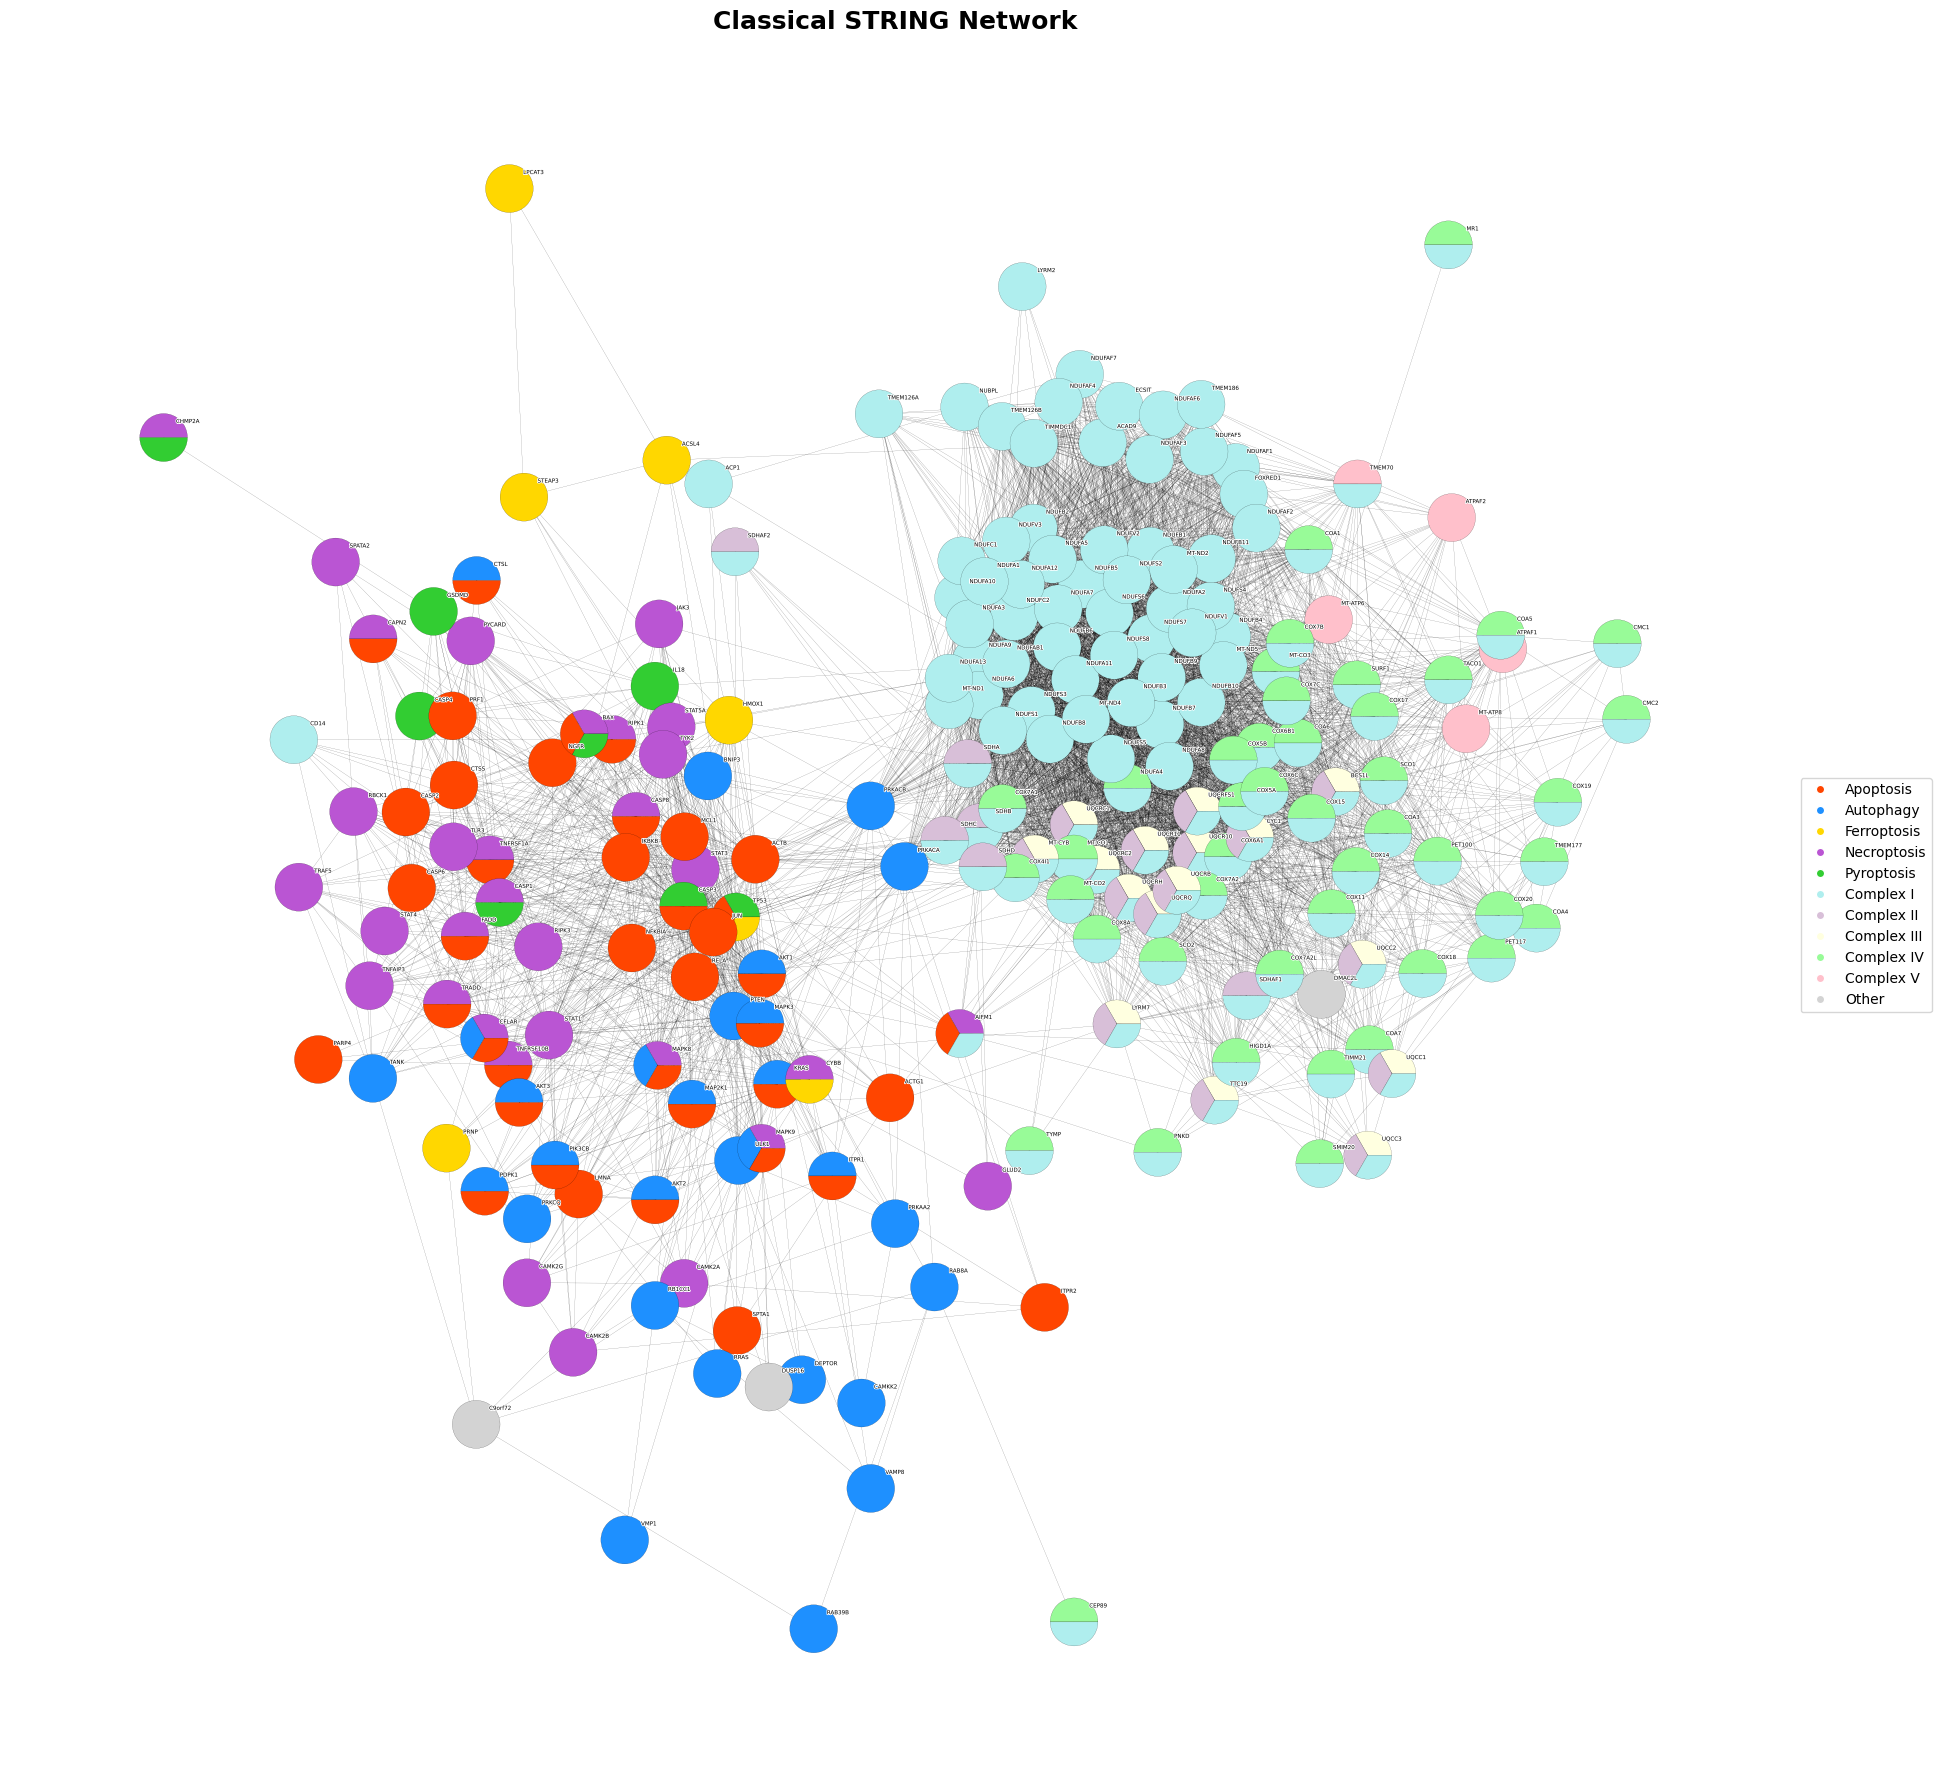

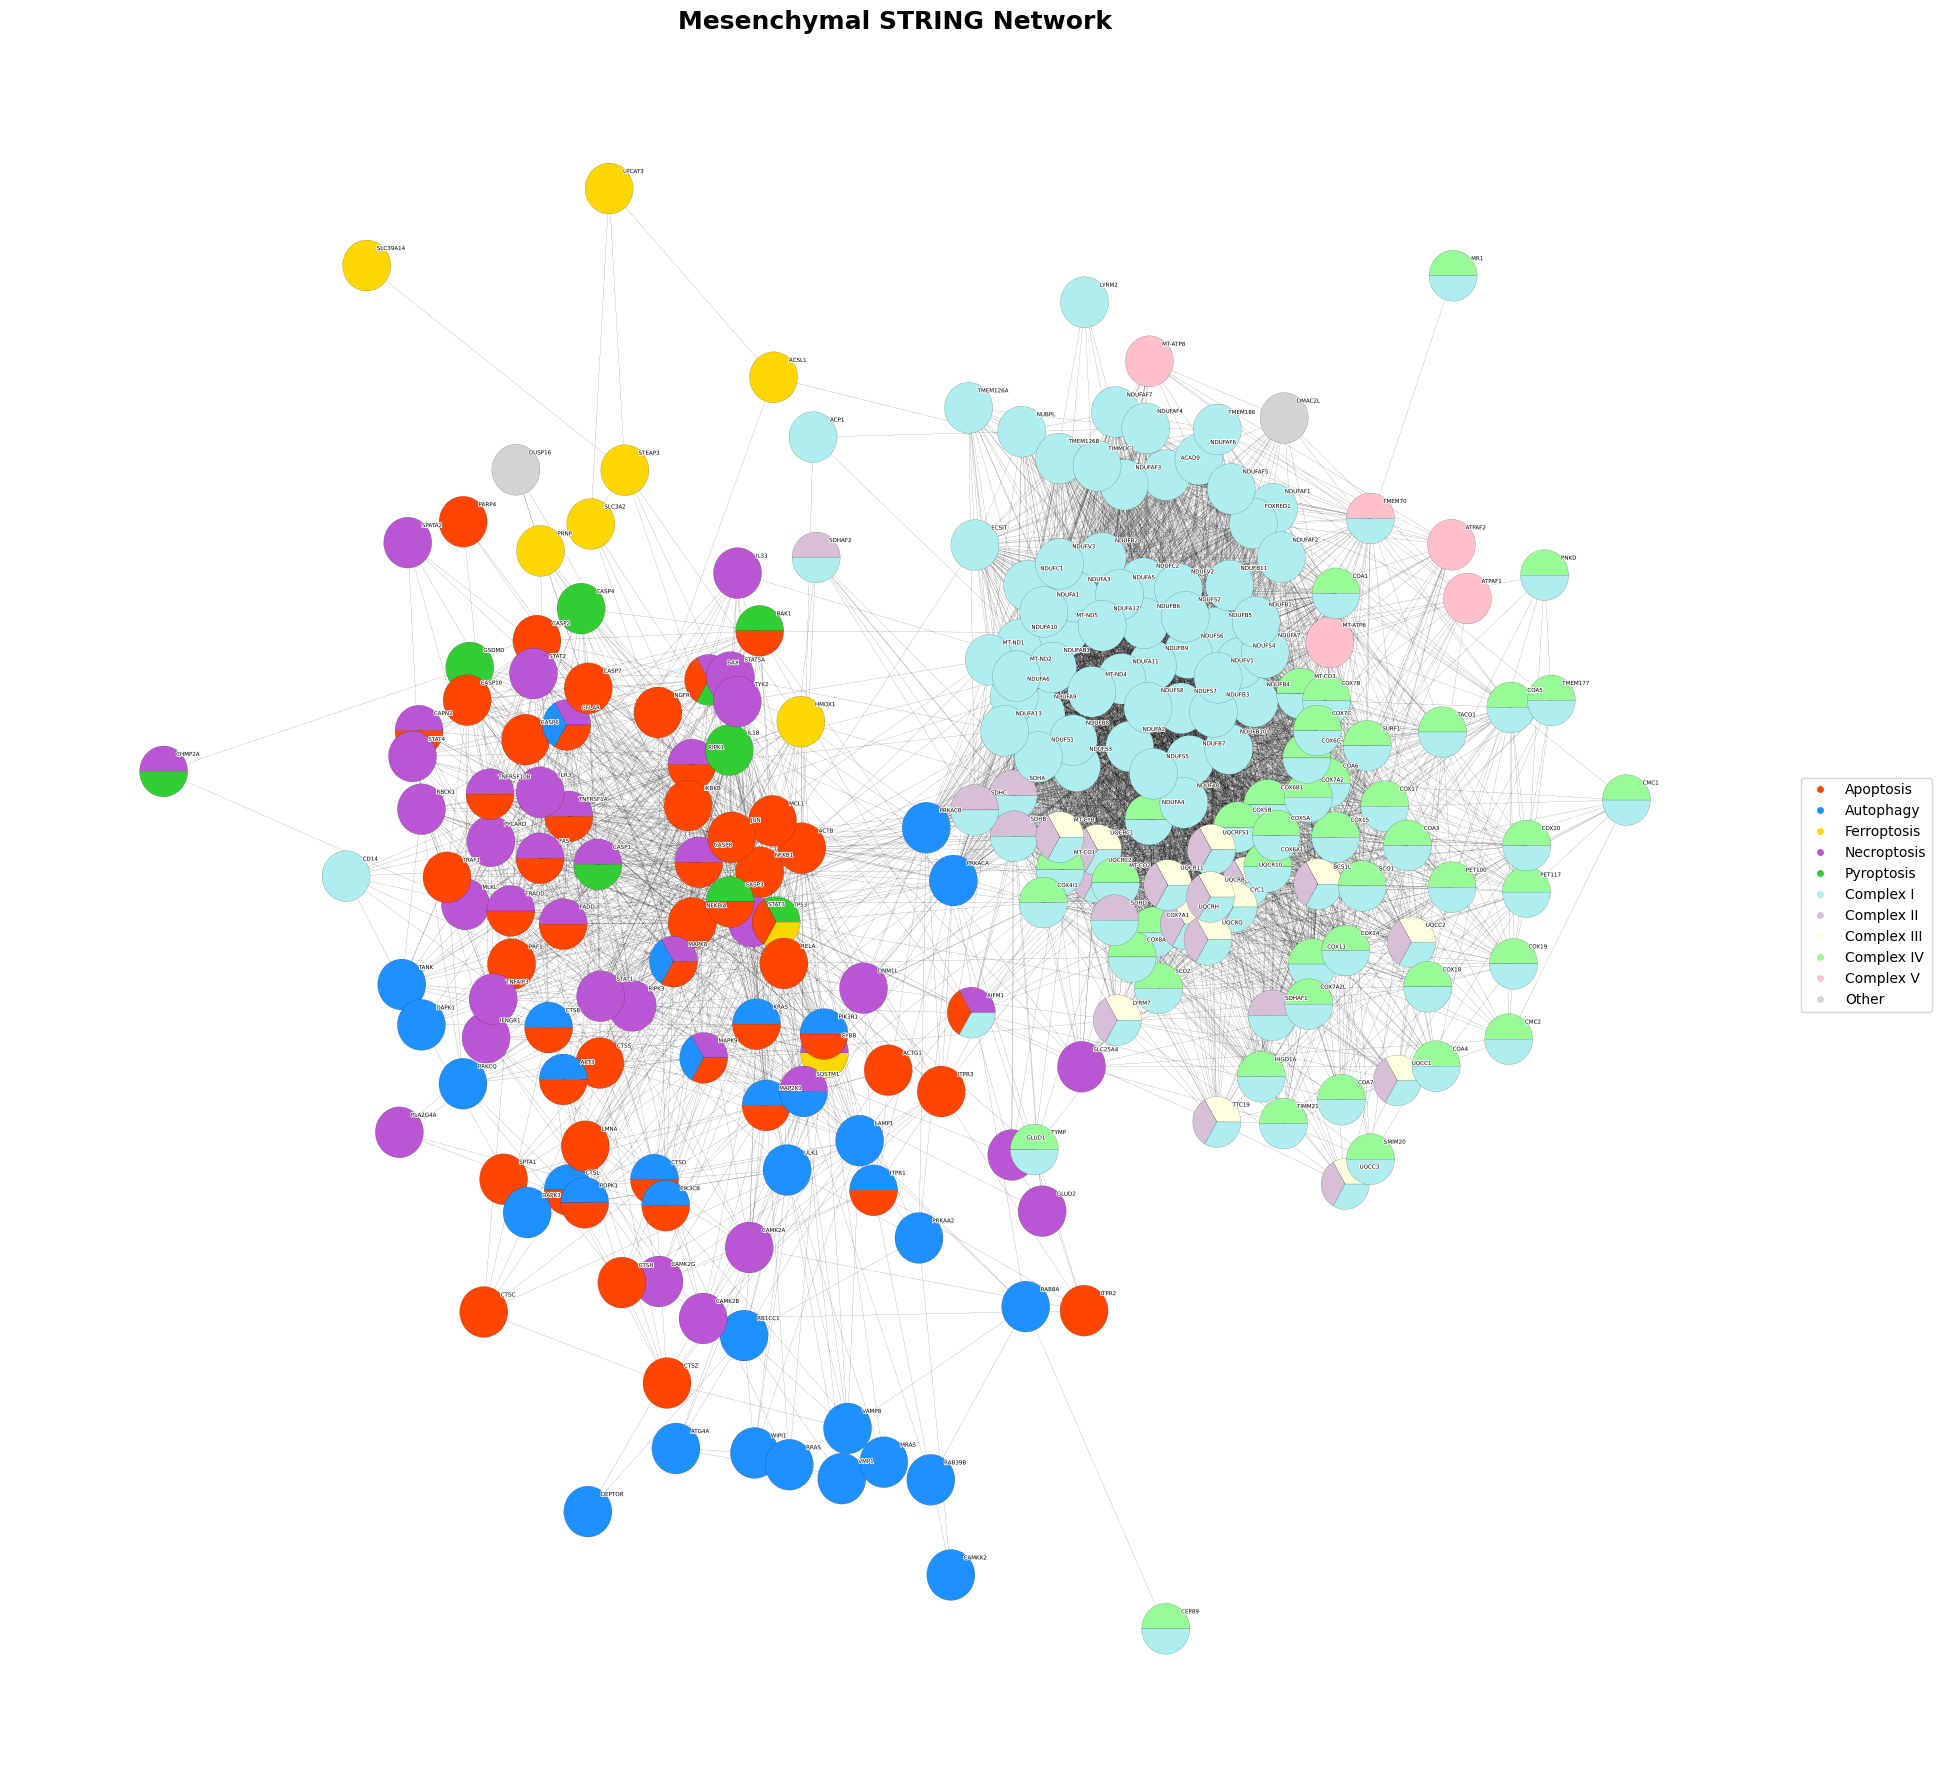

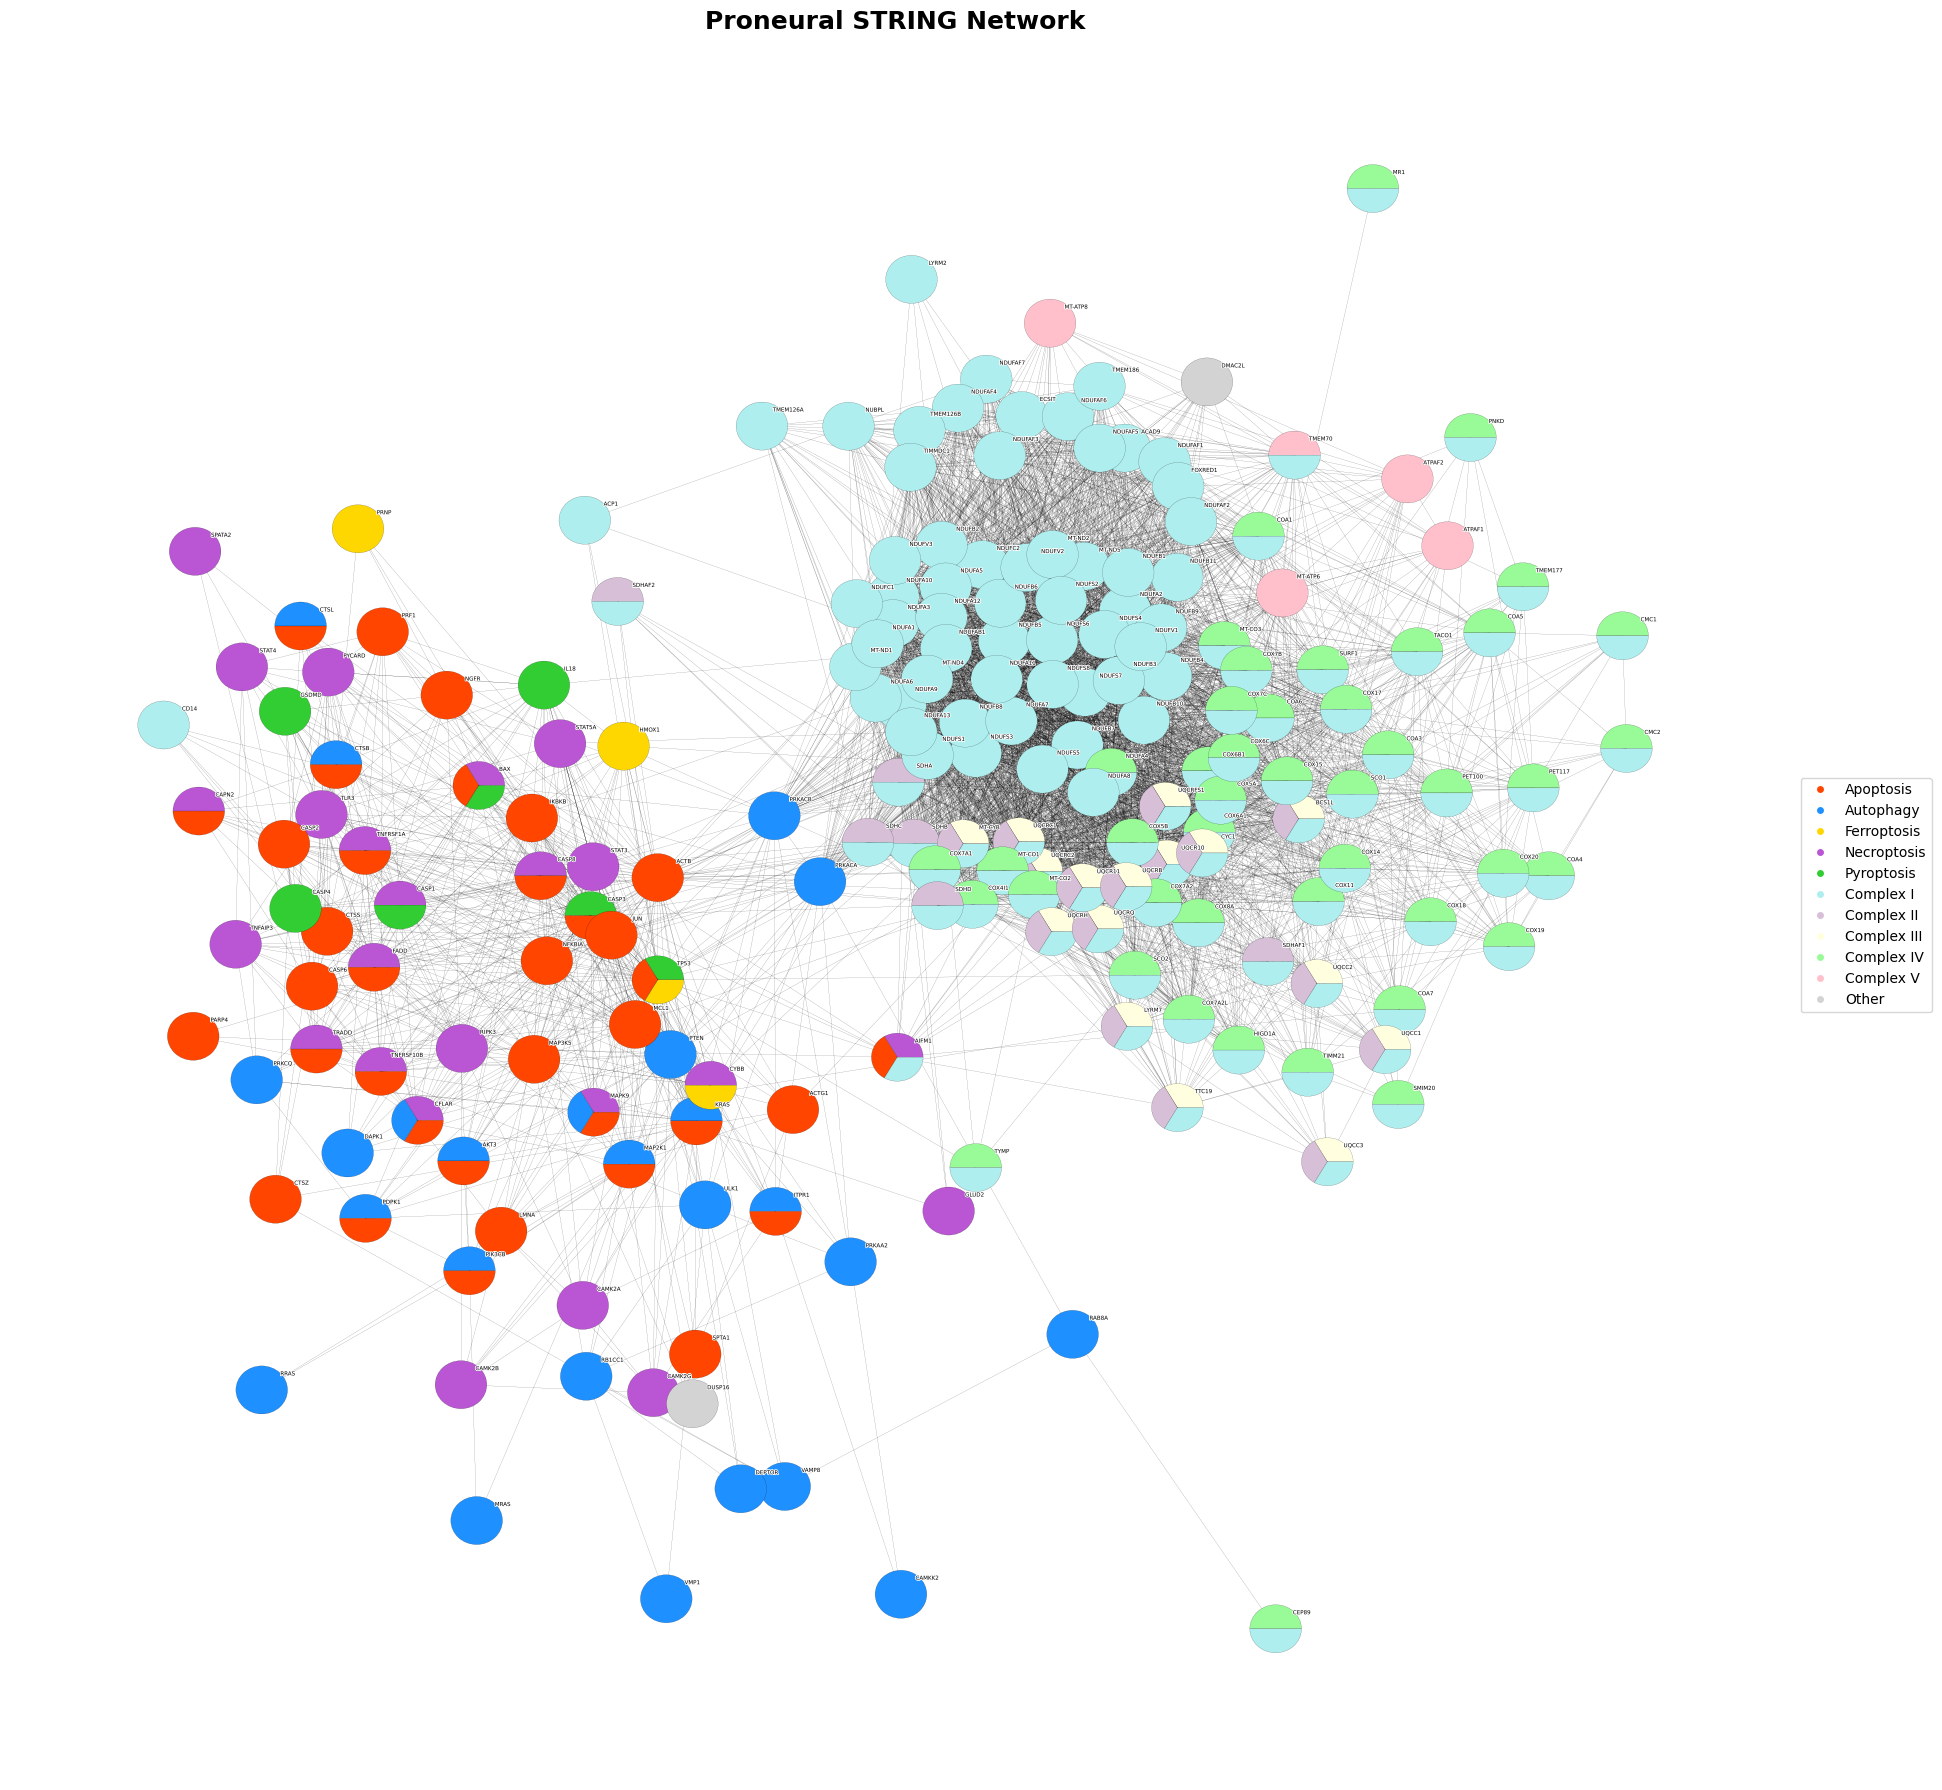

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
from matplotlib.patches import Wedge

for subtype in subtypes:
    G = graphs[subtype]
    print(pathways)
    print(type(pathways))
    # Same layout for all panels
    pos = nx.kamada_kawai_layout(G)

    degree = dict(G.degree())

    labels = {gene: gene for gene in G.nodes()}

    complex_colors = {
        "Complex I": "paleturquoise",
        "Complex II": "thistle",
        "Complex III": "lightyellow",
        "Complex IV": "palegreen",
        "Complex V": "pink"
    }

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(20,14)
    )

    axes = axes.flatten()

    for ax, pathway in zip(axes, pathways):

        node_colors = []

        for gene in G.nodes():

            gene_pathways = G.nodes[gene]["Pathways"]
            gene_complexes = G.nodes[gene]["Complexes"]

            if pathway in gene_pathways:

                node_colors.append("orangered")

            elif len(gene_complexes) > 0:

                node_colors.append(
                    complex_colors.get(
                        gene_complexes[0],
                        "lightgray"
                    )
                )

            else:

                node_colors.append("lightgray")


        # Draw edges first
        nx.draw_networkx_edges(
            G,
            pos,
            edge_color="black",
            width=0.1,
            alpha=0.8,
            ax=ax
        )

        radius = 0.03  # adjust to match your layout

        for gene in G.nodes():

            x, y = pos[gene]

            gene_pathways = G.nodes[gene]["Pathways"]
            gene_complexes = G.nodes[gene]["Complexes"]

            # pathway genes remain solid red
            if pathway in gene_pathways:

                circle = plt.Circle(
                    (x, y),
                    radius,
                    facecolor="orangered",
                    edgecolor="black",
                    linewidth=0.2
                )

                ax.add_patch(circle)

                continue

            # no complex
            if len(gene_complexes) == 0:

                circle = plt.Circle(
                    (x, y),
                    radius,
                    facecolor="lightgray",
                    edgecolor="black",
                    linewidth=0.05
                )

                ax.add_patch(circle)

                continue

            # single complex
            if len(gene_complexes) == 1:

                circle = plt.Circle(
                    (x, y),
                    radius,
                    facecolor=complex_colors[gene_complexes[0]],
                    edgecolor="black",
                    linewidth=0.05
                )

                ax.add_patch(circle)

                continue

            # multiple complexes -> pie chart
            n = len(gene_complexes)

            angle = 360 / n

            for i, comp in enumerate(gene_complexes):

                wedge = Wedge(
                    (x, y),
                    radius,
                    theta1=i * angle,
                    theta2=(i + 1) * angle,
                    facecolor=complex_colors[comp],
                    edgecolor="black",
                    linewidth=0.5,
                    
                )

                ax.add_patch(wedge)

        # Then labels ONCE (offset + white outline)

        label_pos = {
            gene: (xy[0] + 0.03 , xy[1] + 0.02 )
            for gene, xy in pos.items()
        }

        text_items = nx.draw_networkx_labels(
            G,
            label_pos,
            labels=labels,
            font_size=4,
            font_color= "black",
            font_family="sans-serif",
            ax=ax
        )


            
            
            
        ax.set_title(pathway)
        ax.axis("off")

    # remove unused 6th subplot
    axes[-1].axis("off")

    legend = [

        Line2D([0],[0], marker='o', color='w',
            markerfacecolor='red', label='Selected pathway'),

        Line2D([0],[0], marker='o', color='w',
            markerfacecolor='royalblue', label='Complex I'),

        Line2D([0],[0], marker='o', color='w',
            markerfacecolor='green', label='Complex II'),

        Line2D([0],[0], marker='o', color='w',
            markerfacecolor='orange', label='Complex III'),

        Line2D([0],[0], marker='o', color='w',
            markerfacecolor='purple', label='Complex IV'),

        Line2D([0],[0], marker='o', color='w',
            markerfacecolor='brown', label='Complex V'),

        Line2D([0],[0], marker='o', color='w',
            markerfacecolor='lightgray', label='Other')
    ]

    fig.legend(
        handles=legend,
        loc="center right",
        bbox_to_anchor=(1.05,0.5)
    )

    plt.suptitle(
        f"{subtype.capitalize()} STRING network",
        fontsize=18,
        fontweight="bold"
    )

    plt.savefig(f"../data/interim/network_stat/{subtype}_network.svg",format = "svg", bbox_inches="tight")

    plt.tight_layout()
    plt.show()